# Simulador de Cenários de NPS — Tech Challenge

## Visão Geral

Neste notebook simulamos **o impacto de diferentes cenários operacionais** sobre a classificação de NPS dos clientes.

A ideia é responder à pergunta: *"Se a empresa mudar X, quantos clientes migrariam de Detrator para Promotor?"*

Utilizamos o modelo preditivo (Random Forest) treinado com os dados reais e aplicamos modificações controladas nas variáveis operacionais para prever o novo perfil de clientes em cada cenário.

### Boas práticas adotadas

- Uso de `.copy()` para isolar cada cenário sem modificar o conjunto de teste original
- Uso do `X_test` (20% dos dados) como base — dados que o modelo **nunca viu** durante o treino
- Variáveis como `delivery_delay_days` são alteradas de forma controlada para simular situações reais

### Cenários simulados

| # | Cenário | Descrição |
|---|---------|----------|
| 1 | **Atual (Baseline)** | Realidade dos dados de teste sem alteração |
| 2 | **Otimista** | Zero atrasos + tempo de entrega pela metade |
| 3 | **Caótico** | +5 dias de atraso + +3 contatos com o SAC (Black Friday ruim) |

### Instalação de dependências

In [6]:
%pip install pandas scikit-learn matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Importação das bibliotecas

In [7]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

### 1. Carregamento e preparação dos dados

Carregamos o dataset, criamos a variável alvo `nps_class` e preparamos as features para o modelo.

In [8]:
df = pd.read_csv('../../data/raw/desafio_nps_fase_1.csv')

def categorize_nps(score):
    if score <= 6: return 'Detrator'
    elif score <= 8: return 'Neutro'
    else: return 'Promotor'

df['nps_class'] = df['nps_score'].apply(categorize_nps)

print(f'Dataset carregado: {df.shape[0]} linhas x {df.shape[1]} colunas')
df['nps_class'].value_counts(normalize=True).mul(100).round(1).rename('% base real')

Dataset carregado: 2500 linhas x 20 colunas


nps_class
Detrator    74.0
Neutro      17.9
Promotor     8.0
Name: % base real, dtype: float64

### 2. Preparação das features e divisão treino/teste

Removemos colunas identificadoras e a nota original de NPS (para evitar *data leakage*), aplicamos One-Hot Encoding na coluna `customer_region` e preenchemos valores nulos com a mediana.

Dividimos em **80% treino / 20% teste**, mantendo a proporção das classes com `stratify=y`.

In [9]:
X = df.drop(columns=['customer_id', 'order_id', 'nps_score', 'nps_class'])
y = df['nps_class']

X = pd.get_dummies(X, columns=['customer_region'], drop_first=True)
X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')

Treino: 2000 amostras | Teste: 500 amostras


### 3. Treinamento do modelo base

Treinamos um **Random Forest** com 100 árvores. Este modelo será reutilizado em todos os cenários — apenas os dados de entrada (`X_test`) serão modificados.

In [10]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print('Modelo treinado com sucesso!')

Modelo treinado com sucesso!


### 4. Simulação dos Cenários

---

#### Cenário 1 — Atual (Baseline)

Aplicamos o modelo sobre os dados de teste **sem nenhuma alteração**. Este é o retrato da realidade atual dos clientes.

In [11]:
previsoes_real = model.predict(X_test)
resultado_real = pd.Series(previsoes_real).value_counts(normalize=True) * 100

print('Cenário 1 — ATUAL (Baseline):')
print(resultado_real.round(1).to_string() + ' %')

Cenário 1 — ATUAL (Baseline):
Detrator    81.6
Neutro       9.8
Promotor     8.6 %


---

#### Cenário 2 — Otimista (Logística Perfeita)

Simulamos um cenário onde a empresa atingiu excelência operacional:
- `delivery_delay_days = 0` — nenhum pedido atrasou
- `delivery_time_days / 2` — tempo de entrega reduzido pela metade

Usamos `.copy()` para não contaminar os dados originais do cenário base.

In [12]:
X_otimista = X_test.copy()
X_otimista['delivery_delay_days'] = 0
X_otimista['delivery_time_days'] = X_otimista['delivery_time_days'] // 2

previsoes_otimista = model.predict(X_otimista)
resultado_otimista = pd.Series(previsoes_otimista).value_counts(normalize=True) * 100

print('Cenário 2 — OTIMISTA (Logística Perfeita):')
print(resultado_otimista.round(1).to_string() + ' %')

Cenário 2 — OTIMISTA (Logística Perfeita):
Detrator    81.4
Neutro      10.0
Promotor     8.6 %


---

#### Cenário 3 — Caótico (Crise Operacional / Black Friday Ruim)

Simulamos uma situação de colapso operacional, como uma Black Friday mal gerenciada:
- `delivery_delay_days + 5` — todos os pedidos atrasaram 5 dias a mais
- `customer_service_contacts + 3` — todos os clientes precisaram contatar o SAC 3 vezes a mais

In [13]:
X_caotico = X_test.copy()
X_caotico['delivery_delay_days'] = X_caotico['delivery_delay_days'] + 5
X_caotico['customer_service_contacts'] = X_caotico['customer_service_contacts'] + 3

previsoes_caotico = model.predict(X_caotico)
resultado_caotico = pd.Series(previsoes_caotico).value_counts(normalize=True) * 100

print('Cenário 3 — CAÓTICO (Black Friday Ruim):')
print(resultado_caotico.round(1).to_string() + ' %')

Cenário 3 — CAÓTICO (Black Friday Ruim):
Detrator    86.8
Promotor     8.6
Neutro       4.6 %


### 5. Comparação Visual dos Cenários

Consolidamos os três cenários em um **gráfico de barras empilhadas** para facilitar a comparação visual do perfil de clientes em cada situação.

- Vermelho — Detratores
- Amarelo — Neutros
- Verde — Promotores

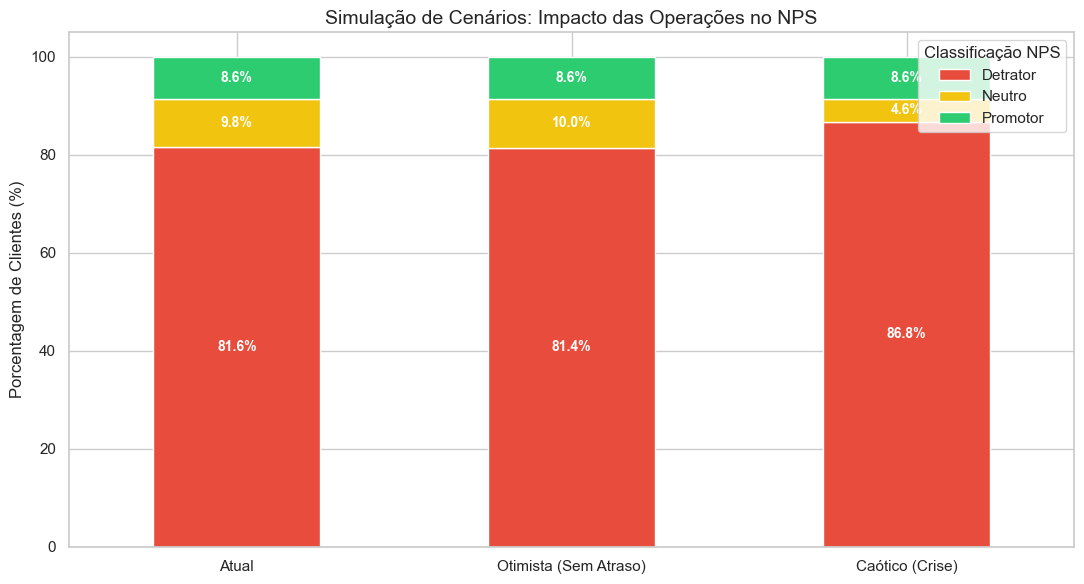

In [14]:
resultados = pd.DataFrame({
    'Atual': resultado_real,
    'Otimista (Sem Atraso)': resultado_otimista,
    'Caótico (Crise)': resultado_caotico,
}).fillna(0).T

resultados = resultados[['Detrator', 'Neutro', 'Promotor']]

ax = resultados.plot(
    kind='bar',
    stacked=True,
    figsize=(11, 6),
    color=['#e74c3c', '#f1c40f', '#2ecc71']
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=10, color='white', fontweight='bold')

plt.title('Simulação de Cenários: Impacto das Operações no NPS', fontsize=14)
plt.ylabel('Porcentagem de Clientes (%)', fontsize=12)
plt.xlabel('')
plt.xticks(rotation=0, fontsize=11)
plt.legend(title='Classificação NPS', loc='upper right')
plt.tight_layout()
plt.show()